In [13]:
# Face Recognition System using OpenCV and Face Recognition

In [14]:
# Install required libraries
!pip install face_recognition

import face_recognition
import cv2
import numpy as np
from google.colab import files
from matplotlib import pyplot as plt

print("Face Recognition System Initialized")

Face Recognition System Initialized


In [15]:
# -------------------------------
# Step 1: Upload known face image
# -------------------------------

print("\nUpload a known person's image:")
known_upload = files.upload()

known_image_path = list(known_upload.keys())[0]

known_image = face_recognition.load_image_file(known_image_path)

known_face_encoding = face_recognition.face_encodings(known_image)[0]

known_faces = [known_face_encoding]
known_names = ["Known Person"]

print("Known face stored successfully.")


Upload a known person's image:


Saving ronaldo.jpg to ronaldo.jpg
Known face stored successfully.


In [16]:
# -------------------------------
# Step 2: Upload test image
# -------------------------------

print("\nUpload image to recognize:")
unknown_upload = files.upload()

unknown_image_path = list(unknown_upload.keys())[0]

unknown_image = face_recognition.load_image_file(unknown_image_path)


Upload image to recognize:


Saving ronaldo1.jpg to ronaldo1.jpg


In [17]:
# Detect faces
face_locations = face_recognition.face_locations(unknown_image)
face_encodings = face_recognition.face_encodings(unknown_image, face_locations)

print("Faces detected:", len(face_locations))

Faces detected: 1


In [18]:
# -------------------------------
# Step 3: Face Recognition
# -------------------------------

image = cv2.imread(unknown_image_path)

for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):

    matches = face_recognition.compare_faces(known_faces, face_encoding)

    name = "Unknown"

    if True in matches:
        match_index = matches.index(True)
        name = known_names[match_index]

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [252, 255, 253],
        [252, 255, 253],
        [252, 255, 253]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [252, 255, 253],
        [252, 255, 253],
        [252, 255, 253]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [252, 255, 253],
        [252, 255, 253],
        [252, 255, 253]],

       ...,

       [[219, 217, 217],
        [222, 220, 220],
        [224, 222, 222],
        ...,
        [217, 207, 207],
        [210, 200, 200],
        [215, 205, 205]],

       [[218, 216, 216],
        [221, 219, 219],
        [225, 223, 223],
        ...,
        [217, 207, 207],
        [210, 200, 200],
        [215, 205, 205]],

       [[217, 215, 215],
        [221, 219, 219],
        [225, 223, 223],
        ...,
        [219, 209, 209],
        [211, 201, 201],
        [216, 206, 206]]], dtype=uint8)
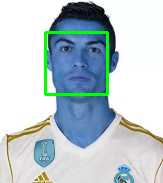

In [19]:
# Draw rectangle
cv2.rectangle(image, (left, top), (right, bottom), (0,255,0), 2)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [252, 255, 253],
        [252, 255, 253],
        [252, 255, 253]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [252, 255, 253],
        [252, 255, 253],
        [252, 255, 253]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       ...,

       [[219, 217, 217],
        [222, 220, 220],
        [224, 222, 222],
        ...,
        [217, 207, 207],
        [210, 200, 200],
        [215, 205, 205]],

       [[218, 216, 216],
        [221, 219, 219],
        [225, 223, 223],
        ...,
        [217, 207, 207],
        [210, 200, 200],
        [215, 205, 205]],

       [[217, 215, 215],
        [221, 219, 219],
        [225, 223, 223],
        ...,
        [219, 209, 209],
        [211, 201, 201],
        [216, 206, 206]]], dtype=uint8)
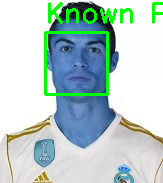

In [20]:
# Draw label
cv2.putText(image, name, (left, top-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,255,0), 2)


Face recognition completed.


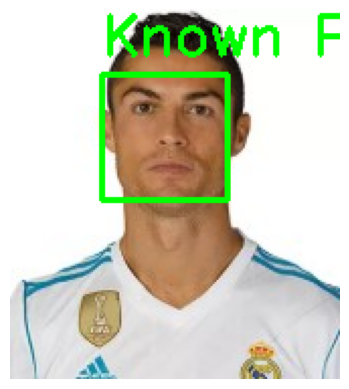

In [21]:
# Show result
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")

print("\nFace recognition completed.")